In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.metrics import (
    recall_score, f1_score,
    roc_auc_score, accuracy_score,
    classification_report, confusion_matrix
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load processed data
X_train = np.load('../data/X_train.npy')
X_test  = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')

print(f"Data loaded successfully!")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Data loaded successfully!
X_train: (614, 8), X_test: (154, 8)


In [3]:
# Before tuning, understand Cross Validation
# 
# Problem with simple train/test split:
# What if by luck, our test set was "easy" data?
# Our model looks great but fails on real users
#
# Cross Validation solution:
# Split training data into 5 equal parts (folds)
# Train on 4 parts, test on 1 part
# Repeat 5 times, each time using different part as test
# Average the 5 results → much more honest evaluation
#
#  Fold 1: [TEST][TRAIN][TRAIN][TRAIN][TRAIN]
#  Fold 2: [TRAIN][TEST][TRAIN][TRAIN][TRAIN]
#  Fold 3: [TRAIN][TRAIN][TEST][TRAIN][TRAIN]
#  Fold 4: [TRAIN][TRAIN][TRAIN][TEST][TRAIN]
#  Fold 5: [TRAIN][TRAIN][TRAIN][TRAIN][TEST]
#  Final score = average of all 5 test scores

# StratifiedKFold keeps same class ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline Random Forest performance with cross validation
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42)

cv_scores = cross_val_score(
    baseline_rf, X_train, y_train,
    cv=cv,
    scoring='recall'  # we care most about recall
)

print("Baseline Random Forest — 5-Fold Cross Validation")
print("=" * 50)
print(f"Recall per fold : {[round(s,4) for s in cv_scores]}")
print(f"Mean Recall     : {cv_scores.mean():.4f}")
print(f"Std Deviation   : {cv_scores.std():.4f}")
print()
print("Low std deviation = model is consistent across different data splits")

Baseline Random Forest — 5-Fold Cross Validation
Recall per fold : [np.float64(0.5581), np.float64(0.5814), np.float64(0.5814), np.float64(0.5814), np.float64(0.5952)]
Mean Recall     : 0.5795
Std Deviation   : 0.0120

Low std deviation = model is consistent across different data splits


In [4]:
print("""
GRIDSEARCHCV vs RANDOMIZEDSEARCHCV
====================================

GridSearchCV:
  → Tries EVERY possible combination
  → Example: 4 values × 3 values × 3 values = 36 combinations
  → Each combination × 5 folds = 180 training runs
  → Guaranteed to find the best combination
  → BUT very slow for large parameter spaces

RandomizedSearchCV:
  → Randomly tries N combinations (you choose N)
  → Example: only try 20 random combinations × 5 folds = 100 runs
  → Faster, good enough for large spaces
  → May miss the absolute best but finds very good results

RULE OF THUMB:
  Small parameter space (< 50 combos) → GridSearchCV
  Large parameter space (> 50 combos) → RandomizedSearchCV

We will use RandomizedSearchCV first to narrow down
then GridSearchCV to fine-tune
""")



GRIDSEARCHCV vs RANDOMIZEDSEARCHCV

GridSearchCV:
  → Tries EVERY possible combination
  → Example: 4 values × 3 values × 3 values = 36 combinations
  → Each combination × 5 folds = 180 training runs
  → Guaranteed to find the best combination
  → BUT very slow for large parameter spaces

RandomizedSearchCV:
  → Randomly tries N combinations (you choose N)
  → Example: only try 20 random combinations × 5 folds = 100 runs
  → Faster, good enough for large spaces
  → May miss the absolute best but finds very good results

RULE OF THUMB:
  Small parameter space (< 50 combos) → GridSearchCV
  Large parameter space (> 50 combos) → RandomizedSearchCV

We will use RandomizedSearchCV first to narrow down
then GridSearchCV to fine-tune



In [5]:
# Define a WIDE range of hyperparameters to search
# We cast a big net first

param_distributions = {
    'n_estimators': [50, 100, 200, 300, 500],
    # number of trees — more trees = more stable but slower

    'max_depth': [None, 5, 10, 15, 20],
    # how deep each tree grows
    # None = unlimited (can overfit)
    # Small number = simpler tree (less overfit)

    'min_samples_split': [2, 5, 10, 15],
    # minimum samples needed to split a node
    # Higher = simpler tree = less overfit

    'min_samples_leaf': [1, 2, 4, 6],
    # minimum samples required at leaf node
    # Higher = smoother decision boundary

    'max_features': ['sqrt', 'log2', None],
    # number of features to consider at each split
    # 'sqrt' = square root of total features (default, recommended)

    'class_weight': ['balanced', None]
    # 'balanced' = automatically handles class imbalance
    # gives more weight to minority class (diabetic patients)
}

print("Starting RandomizedSearchCV...")
print("This will try 50 random combinations × 5 folds = 250 training runs")
print("Please wait 1-2 minutes...\n")

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=50,          # try 50 random combinations
    cv=cv,              # 5-fold stratified cross validation
    scoring='recall',   # optimize for recall
    n_jobs=-1,          # use all CPU cores
    random_state=42,
    verbose=1           # show progress
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param:20}: {value}")
print(f"\nBest CV Recall: {random_search.best_score_:.4f}")

Starting RandomizedSearchCV...
This will try 50 random combinations × 5 folds = 250 training runs
Please wait 1-2 minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
  n_estimators        : 300
  min_samples_split   : 2
  min_samples_leaf    : 6
  max_features        : None
  max_depth           : 5
  class_weight        : balanced

Best CV Recall: 0.7382


In [6]:
# Take the best params from RandomizedSearch
# Search more carefully in a smaller range AROUND those values

best = random_search.best_params_

# Build a narrow grid around the best values found
param_grid = {
    'n_estimators'    : [
        max(50, best['n_estimators'] - 50),
        best['n_estimators'],
        best['n_estimators'] + 50
    ],
    'max_depth'       : [best['max_depth']],
    'min_samples_split': [
        max(2, best['min_samples_split'] - 2),
        best['min_samples_split'],
        best['min_samples_split'] + 2
    ],
    'min_samples_leaf': [
        max(1, best['min_samples_leaf'] - 1),
        best['min_samples_leaf'],
        best['min_samples_leaf'] + 1
    ],
    'max_features'    : [best['max_features']],
    'class_weight'    : [best['class_weight']]
}

print("Starting GridSearchCV (fine-tuning)...")
print("Please wait 1-2 minutes...\n")

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nFinal best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:20}: {value}")
print(f"\nBest CV Recall: {grid_search.best_score_:.4f}")

Starting GridSearchCV (fine-tuning)...
Please wait 1-2 minutes...

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Final best parameters:
  class_weight        : balanced
  max_depth           : 5
  max_features        : None
  min_samples_leaf    : 5
  min_samples_split   : 2
  n_estimators        : 250

Best CV Recall: 0.7382


In [7]:
# Train baseline model
baseline = RandomForestClassifier(n_estimators=100, random_state=42)
baseline.fit(X_train, y_train)

# Best tuned model
tuned = grid_search.best_estimator_

# Evaluate both
def quick_eval(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4)
    }

baseline_results = quick_eval("Baseline RF", baseline, X_test, y_test)
tuned_results    = quick_eval("Tuned RF",    tuned,    X_test, y_test)

comparison = pd.DataFrame([baseline_results, tuned_results]).set_index('Model')
print("BASELINE vs TUNED MODEL")
print("=" * 50)
print(comparison.to_string())
print()

# Show improvement
for metric in ['Accuracy', 'Recall', 'F1 Score', 'ROC-AUC']:
    diff = tuned_results[metric] - baseline_results[metric]
    arrow = "↑" if diff > 0 else "↓" if diff < 0 else "→"
    print(f"  {metric:12}: {arrow} {abs(diff):.4f} {'improvement' if diff > 0 else 'decrease' if diff < 0 else 'no change'}")

BASELINE vs TUNED MODEL
             Accuracy  Recall  F1 Score  ROC-AUC
Model                                           
Baseline RF    0.7727  0.6111    0.6535   0.8181
Tuned RF       0.7727  0.7593    0.7009   0.8300

  Accuracy    : → 0.0000 no change
  Recall      : ↑ 0.1482 improvement
  F1 Score    : ↑ 0.0474 improvement
  ROC-AUC     : ↑ 0.0119 improvement


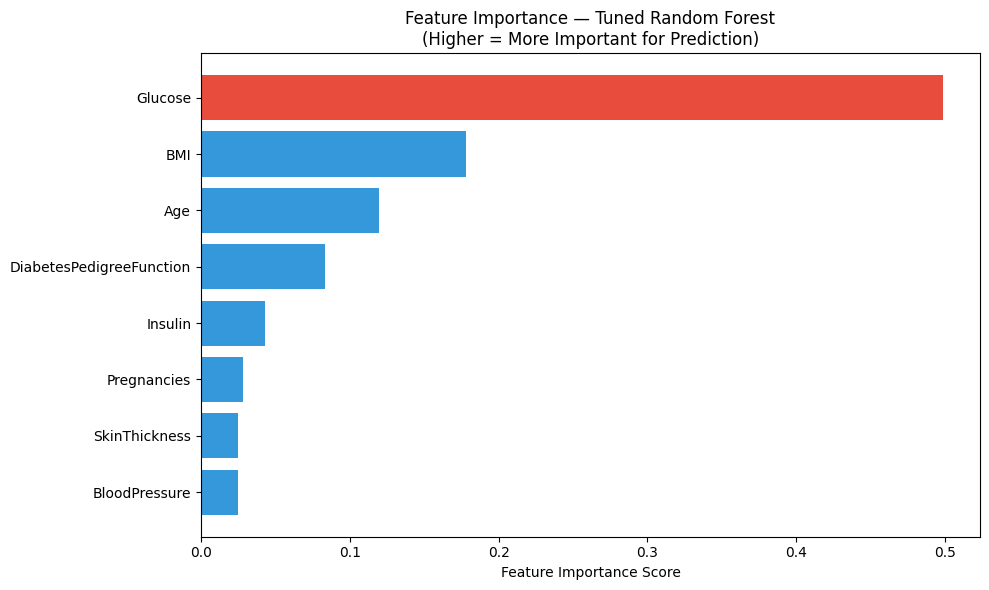

Feature Importance Ranking:
  1. Glucose                     : 0.4985  █████████████████████████████████████████████████
  2. BMI                         : 0.1779  █████████████████
  3. Age                         : 0.1195  ███████████
  4. DiabetesPedigreeFunction    : 0.0832  ████████
  5. Insulin                     : 0.0429  ████
  6. Pregnancies                 : 0.0280  ██
  7. SkinThickness               : 0.0252  ██
  8. BloodPressure               : 0.0248  ██

Medical interpretation:
  → Glucose is #1 — matches real diabetes diagnosis criteria
  → BMI is high — obesity is a major diabetes risk factor
  → Age matters — diabetes risk increases with age
  → DiabetesPedigreeFunction — genetic/family history matters


In [8]:
# Feature importance tells us:
# "Which health features matter most for predicting diabetes?"
# This is extremely valuable for:
#   1. Understanding your model (explainability)
#   2. Telling doctors which factors to watch
#   3. Interview discussions — you can explain your model's decisions

feature_names = [
    'Pregnancies', 'Glucose', 'BloodPressure',
    'SkinThickness', 'Insulin', 'BMI',
    'DiabetesPedigreeFunction', 'Age'
]

# Get importance scores from tuned model
importances = tuned.feature_importances_
# Each value = how much that feature contributes to predictions
# All values add up to 1.0 (100%)

# Sort from most to least important
indices = np.argsort(importances)[::-1]
sorted_features    = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(sorted_features))]
bars = plt.barh(sorted_features[::-1], sorted_importances[::-1], color=colors[::-1])
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Tuned Random Forest\n(Higher = More Important for Prediction)')
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
print("=" * 45)
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances)):
    bar = "█" * int(imp * 100)
    print(f"  {i+1}. {feat:28}: {imp:.4f}  {bar}")

print()
print("Medical interpretation:")
print("  → Glucose is #1 — matches real diabetes diagnosis criteria")
print("  → BMI is high — obesity is a major diabetes risk factor")
print("  → Age matters — diabetes risk increases with age")
print("  → DiabetesPedigreeFunction — genetic/family history matters")

In [9]:
# Overfitting = model memorizes training data
#               performs great on training, terrible on new data
# Like a student who memorizes answers without understanding

train_recall = recall_score(y_train, tuned.predict(X_train))
test_recall  = recall_score(y_test,  tuned.predict(X_test))

train_acc = accuracy_score(y_train, tuned.predict(X_train))
test_acc  = accuracy_score(y_test,  tuned.predict(X_test))

print("OVERFITTING CHECK")
print("=" * 40)
print(f"  Train Recall   : {train_recall:.4f}")
print(f"  Test  Recall   : {test_recall:.4f}")
print(f"  Gap            : {train_recall - test_recall:.4f}")
print()
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {test_acc:.4f}")
print(f"  Gap            : {train_acc - test_acc:.4f}")
print()

gap = train_acc - test_acc
if gap < 0.05:
    print("✅ Gap < 5% → Model is NOT overfitting. Healthy generalization.")
elif gap < 0.10:
    print("⚠️  Gap 5-10% → Mild overfitting. Acceptable for this dataset.")
else:
    print("❌ Gap > 10% → Model is overfitting. Needs more regularization.")

OVERFITTING CHECK
  Train Recall   : 0.8551
  Test  Recall   : 0.7593
  Gap            : 0.0959

  Train Accuracy : 0.8371
  Test  Accuracy : 0.7727
  Gap            : 0.0644

⚠️  Gap 5-10% → Mild overfitting. Acceptable for this dataset.


In [10]:
# Save tuned model — this REPLACES the previous best_model
joblib.dump(tuned, '../models/best_model.joblib')
joblib.dump(tuned, '../models/random_forest_tuned.joblib')

# Save feature names for the API to use later
import json
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Saved:")
print("  → models/best_model.joblib           ← API uses this")
print("  → models/random_forest_tuned.joblib  ← backup")
print("  → models/feature_names.json          ← feature names for API")
print()
print("=" * 50)
print("PHASE 5 COMPLETE")
print("=" * 50)
print(f"Final model  : Tuned Random Forest")
print(f"Final Recall : {test_recall:.4f}")
print(f"Final ROC-AUC: {roc_auc_score(y_test, tuned.predict_proba(X_test)[:,1]):.4f}")

Saved:
  → models/best_model.joblib           ← API uses this
  → models/random_forest_tuned.joblib  ← backup
  → models/feature_names.json          ← feature names for API

PHASE 5 COMPLETE
Final model  : Tuned Random Forest
Final Recall : 0.7593
Final ROC-AUC: 0.8300
